In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

In [2]:
import numpy as np
import pandas as pd

In [3]:
# read chibio
m = pd.read_csv('data/PN23/chibio.tsv.gz', sep='\t')
# read plate counts
c = pd.read_csv('data/PN23/plate_counts.tsv', sep='\t')
# read plate reader fluorescence
# p = pd.read_csv('data/pOXA48/plate_reader_fluorescence.tsv', sep='\t')
# read flow cytometer
# f = pd.read_csv('data/pOXA48/flow_cytometer.tsv', sep='\t')

In [4]:
short_order = ['KAN no drug',
               'PN23 no drug',
               'KAN 1xMIC',
               'PN23 1xMIC',
               'KAN 2xMIC',
               'PN23 2xMIC',
               'KAN+PN23 2xMIC',]

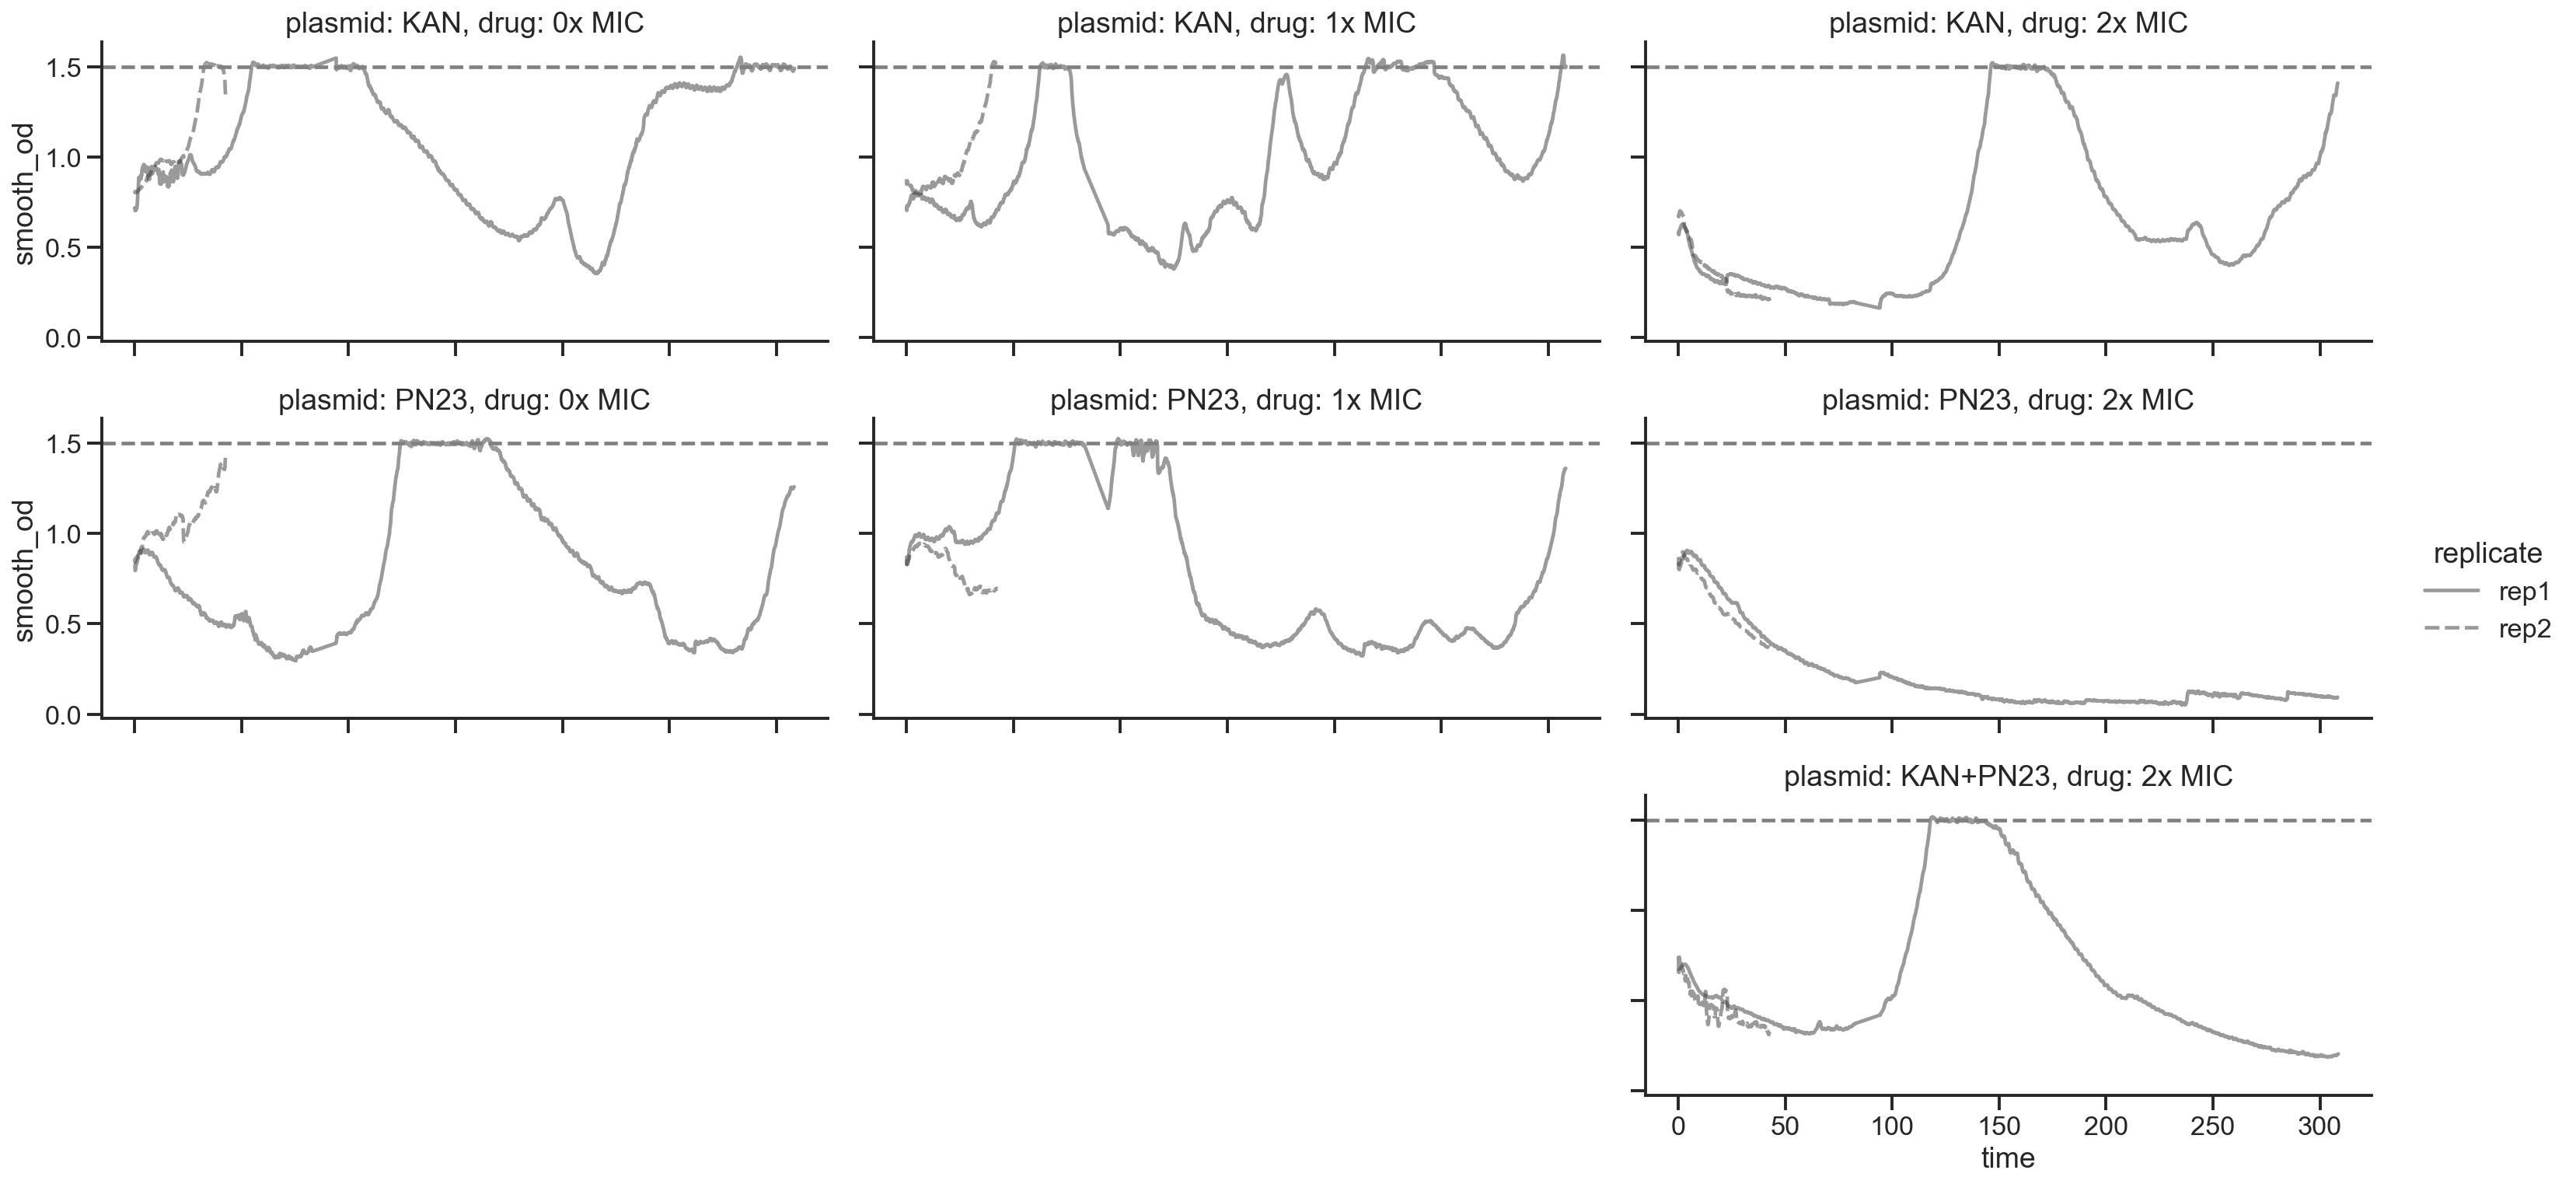

In [5]:
cp = sns.relplot(data=m,
                 x='time',
                 y='smooth_od',
                 col='drug',
                 style='replicate',
                 row='plasmid',
                 row_order=['KAN', 'PN23', 'KAN+PN23'],
                 kind='line',
                 height=3.5, aspect=2,
                 color='xkcd:dark grey',
                 alpha=0.5,
                )

# remove axes 7 and 8
cp.axes[2, 0].set_visible(False)
cp.axes[2, 1].set_visible(False)

# cp.set(yscale='log')
cp.set_titles("plasmid: {row_name}, drug: {col_name}x MIC")
cp.map(plt.axhline, y=1.5, color='grey', linestyle='--');

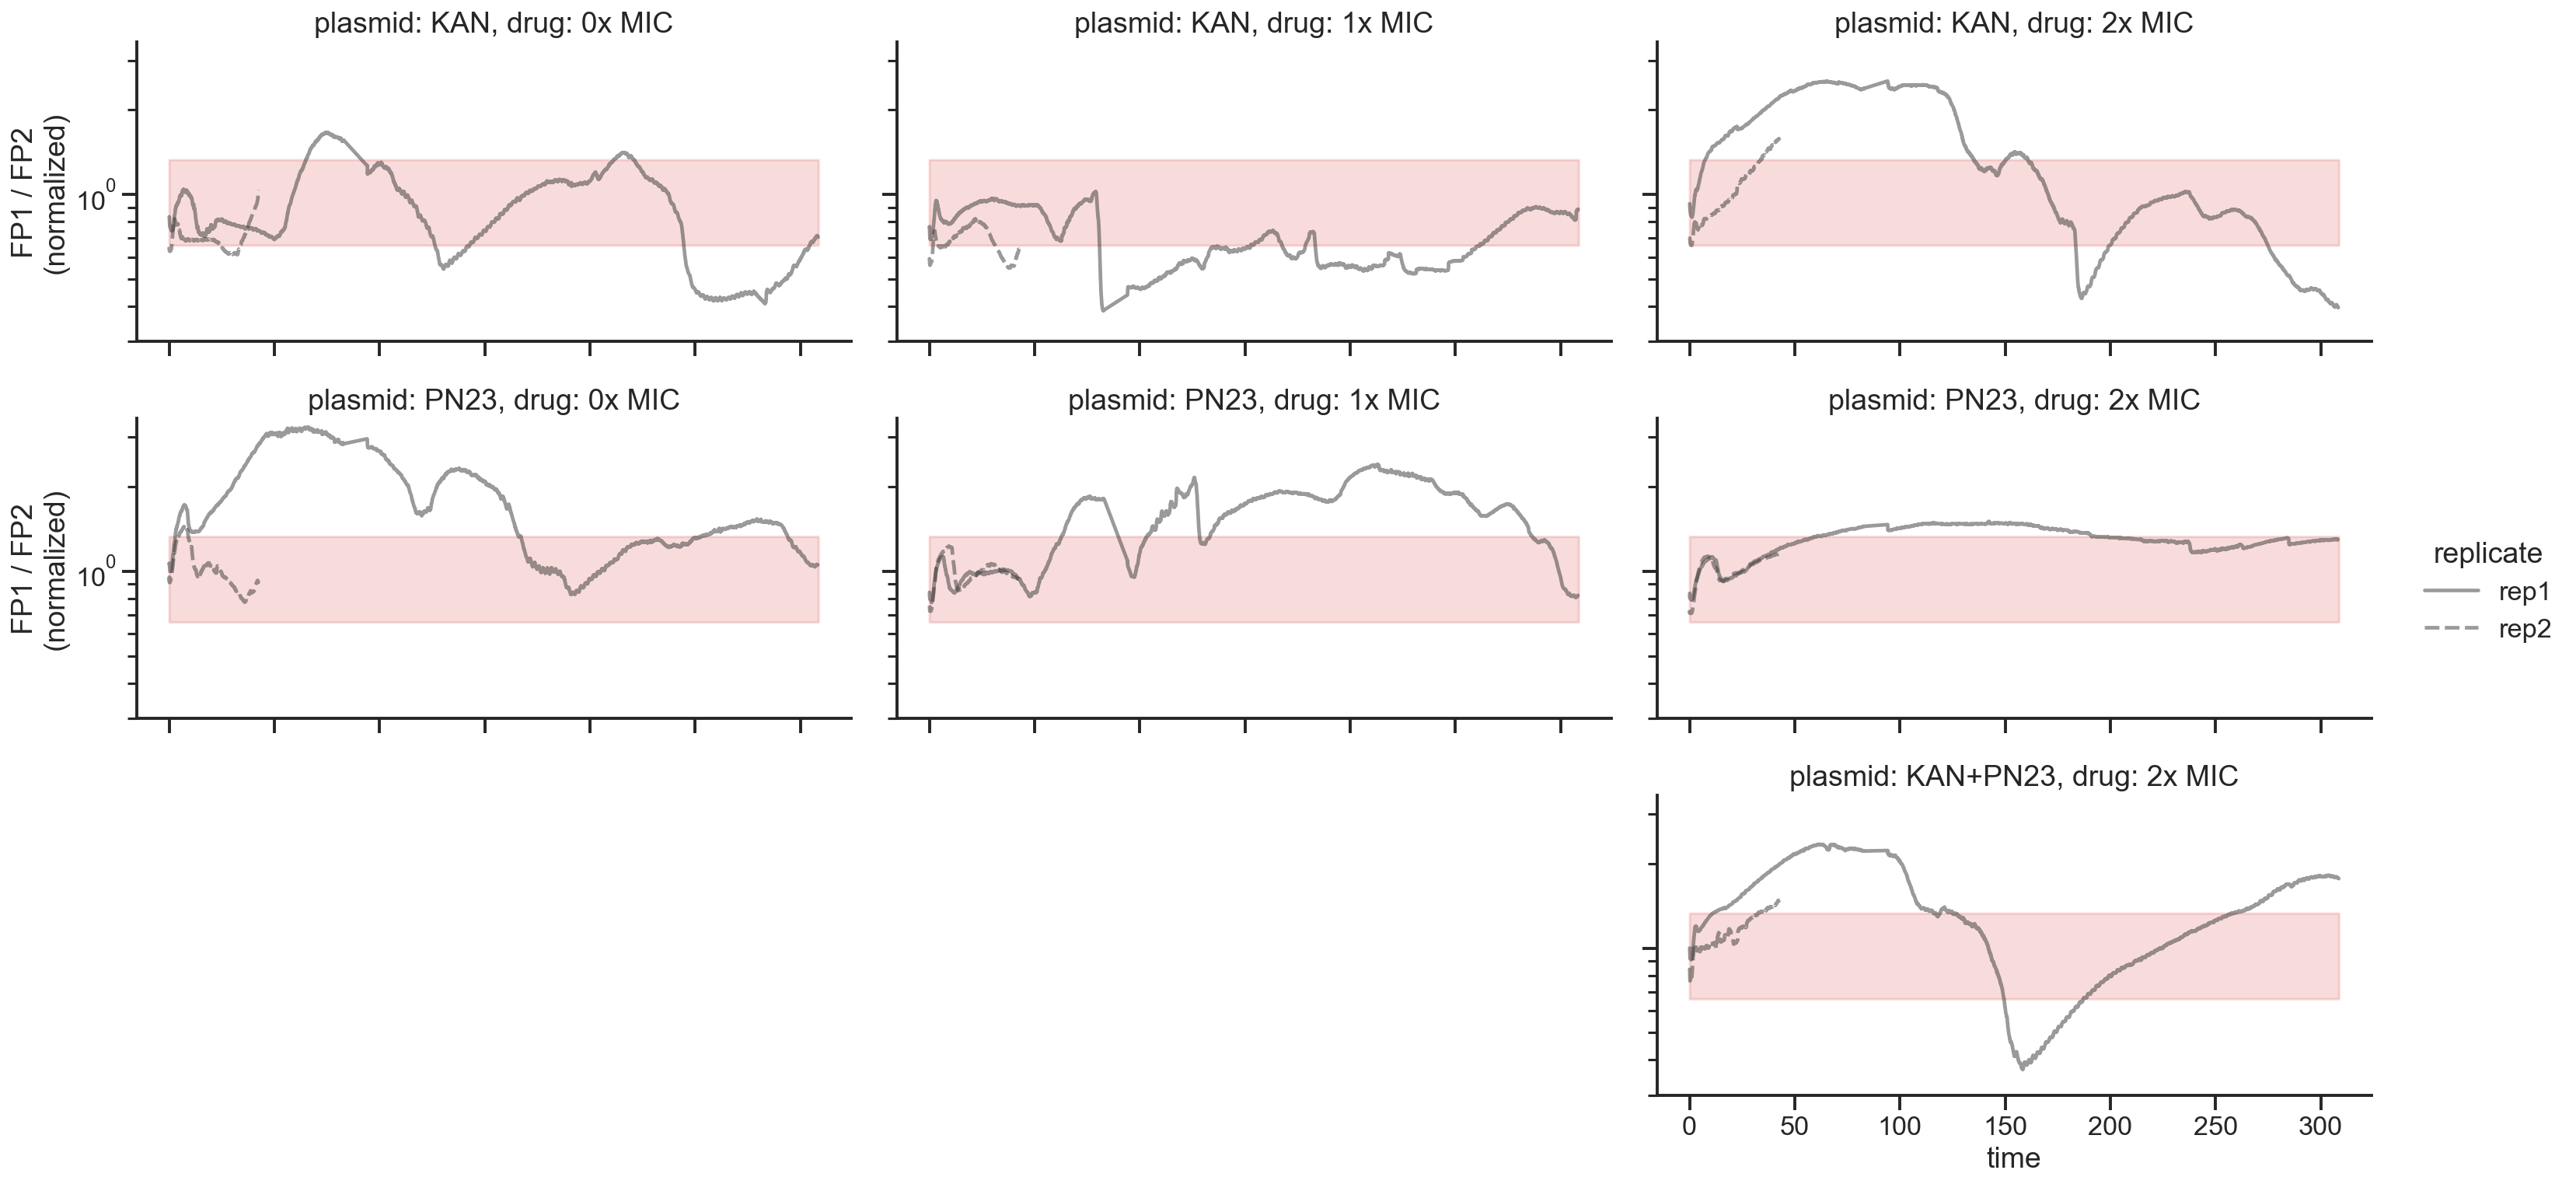

In [6]:
cp = sns.relplot(data=m,
                 x='time',
                 y='smooth_norm_FP1_emit1_FP2_emit1_ratio',
                 col='drug',
                 style='replicate',
                 row='plasmid',
                 row_order=['KAN', 'PN23', 'KAN+PN23'],
                 kind='line',
                 height=3.5, aspect=2,
                 color='xkcd:dark grey',
                 alpha=0.5,
                )

# remove axes 7 and 8
cp.axes[2, 0].set_visible(False)
cp.axes[2, 1].set_visible(False)

# cp.set(yscale='log')
cp.set_titles("plasmid: {row_name}, drug: {col_name}x MIC")
cp.set(ylabel='FP1 / FP2\n(normalized)', yscale='log',
       ylim=(0.3, 3.5))

cp.map(plt.fill_between, 
        x=sorted(m['time'].unique()), 
        y1=0.66, 
        y2=1.33, 
        color='xkcd:pale red', 
        alpha=0.2);

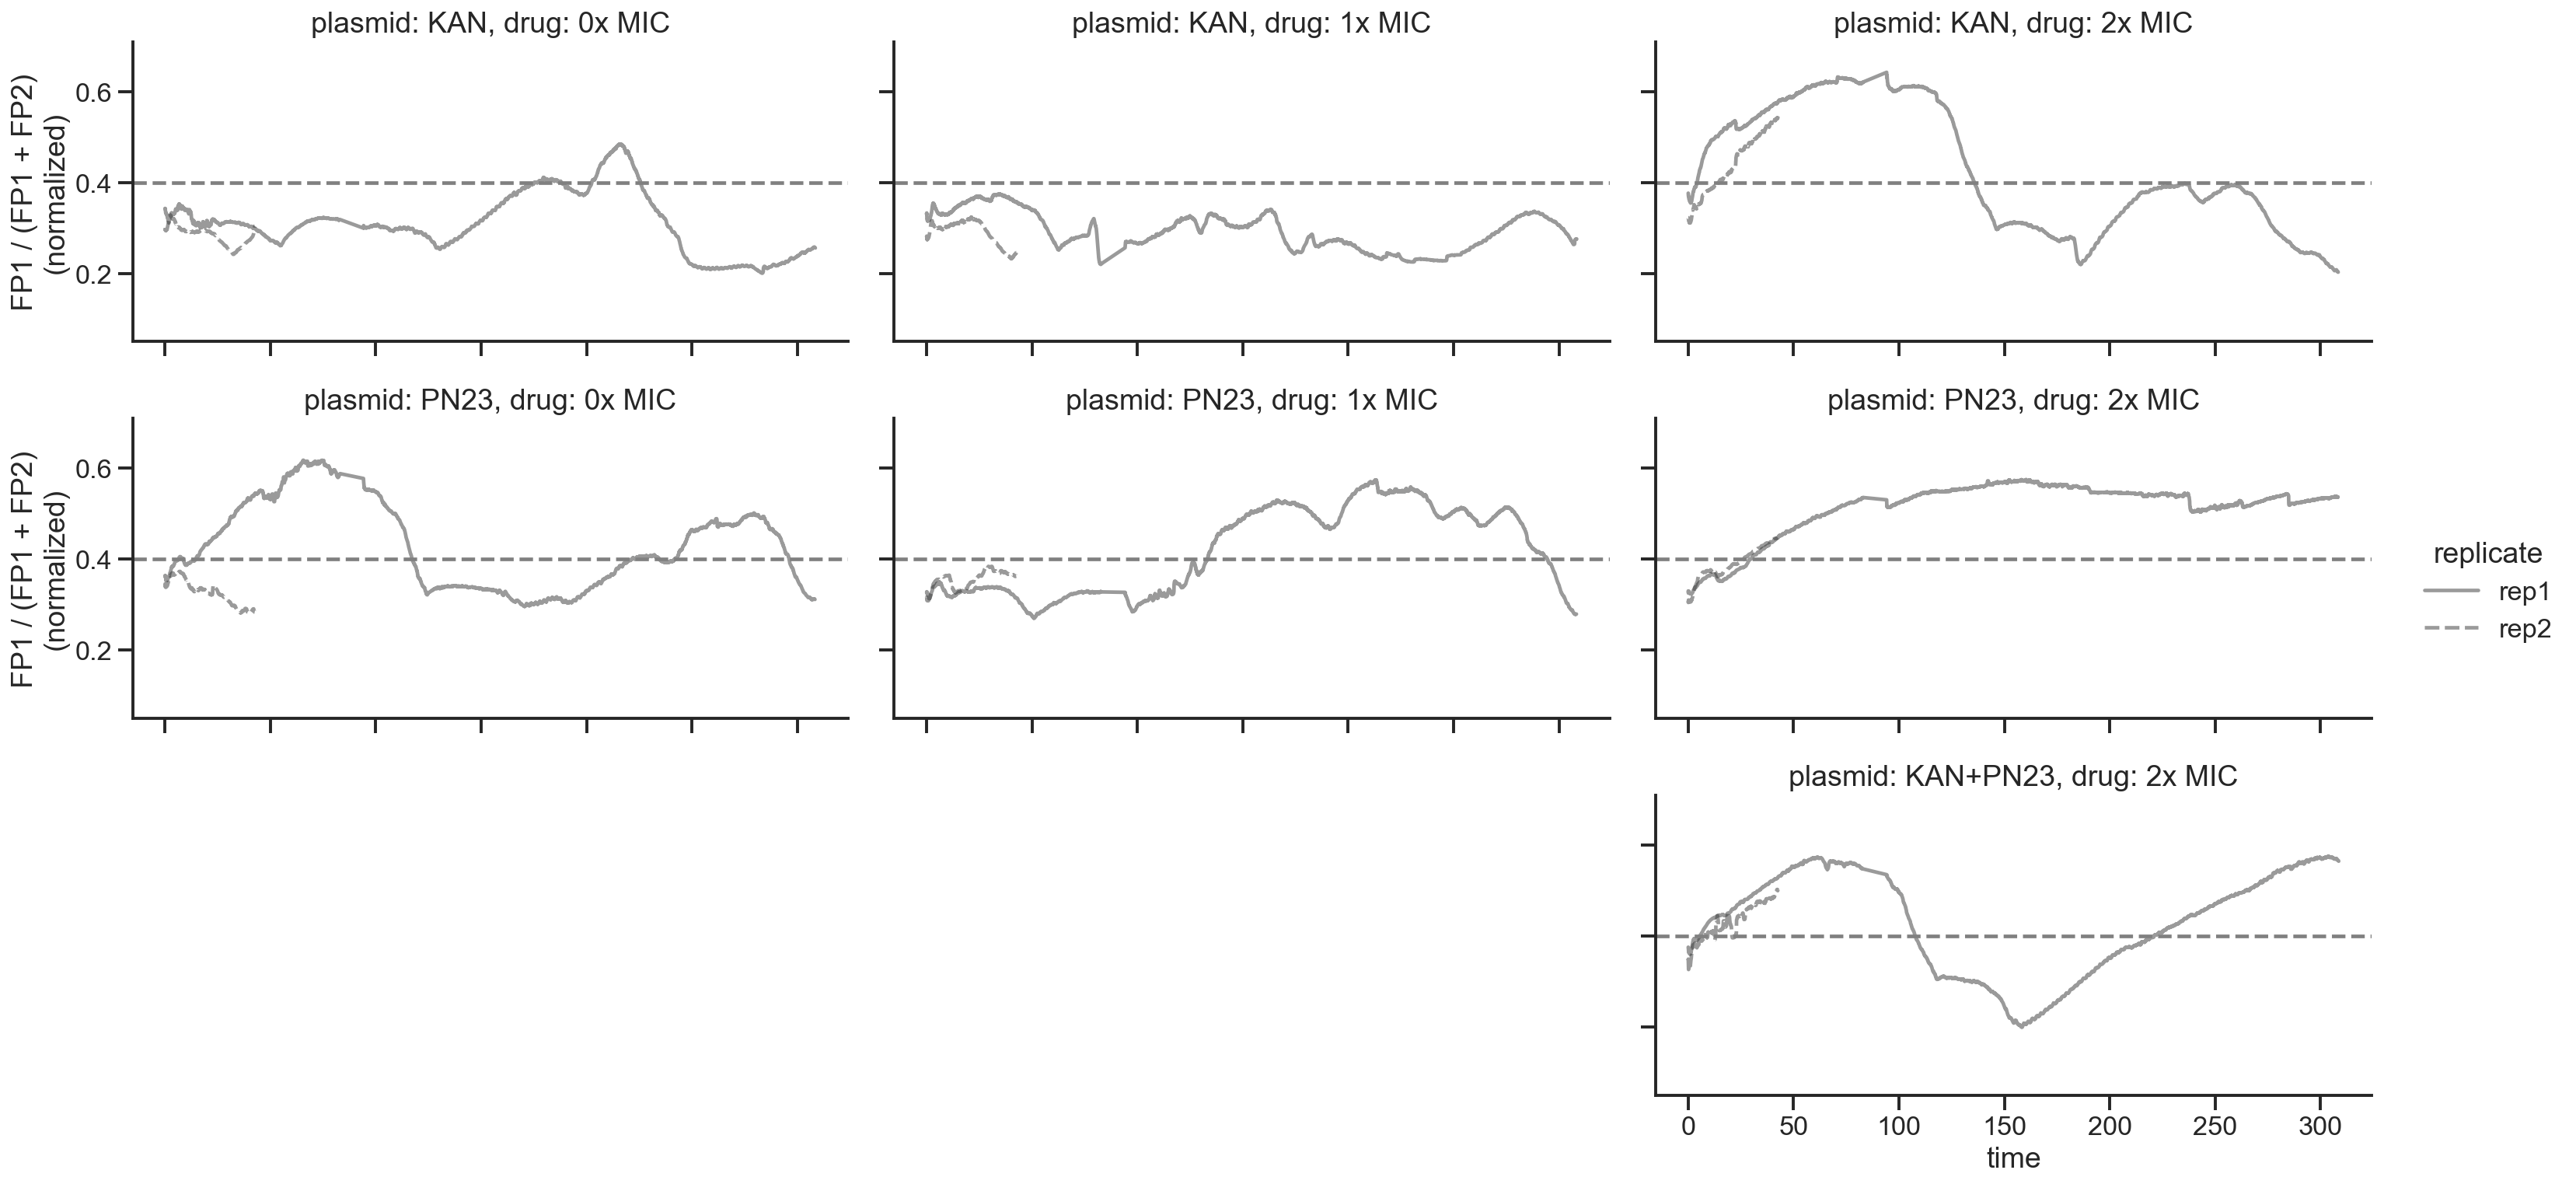

In [7]:
cp = sns.relplot(data=m,
                 x='time',
                 y='smooth_norm_FP1_emit1_FP2_emit1_proportion',
                 col='drug',
                 style='replicate',
                 row='plasmid',
                 row_order=['KAN', 'PN23', 'KAN+PN23'],
                 kind='line',
                 height=3.5, aspect=2,
                 color='xkcd:dark grey',
                 alpha=0.5,
                )

# remove axes 7 and 8
cp.axes[2, 0].set_visible(False)
cp.axes[2, 1].set_visible(False)

# cp.set(yscale='log')
cp.set_titles("plasmid: {row_name}, drug: {col_name}x MIC")
cp.set(ylabel='FP1 / (FP1 + FP2)\n(normalized)',
       # yscale='log',
       ylim=(0.05, 0.71)
      )

cp.map(plt.axhline, y=0.4, color='grey', linestyle='--');

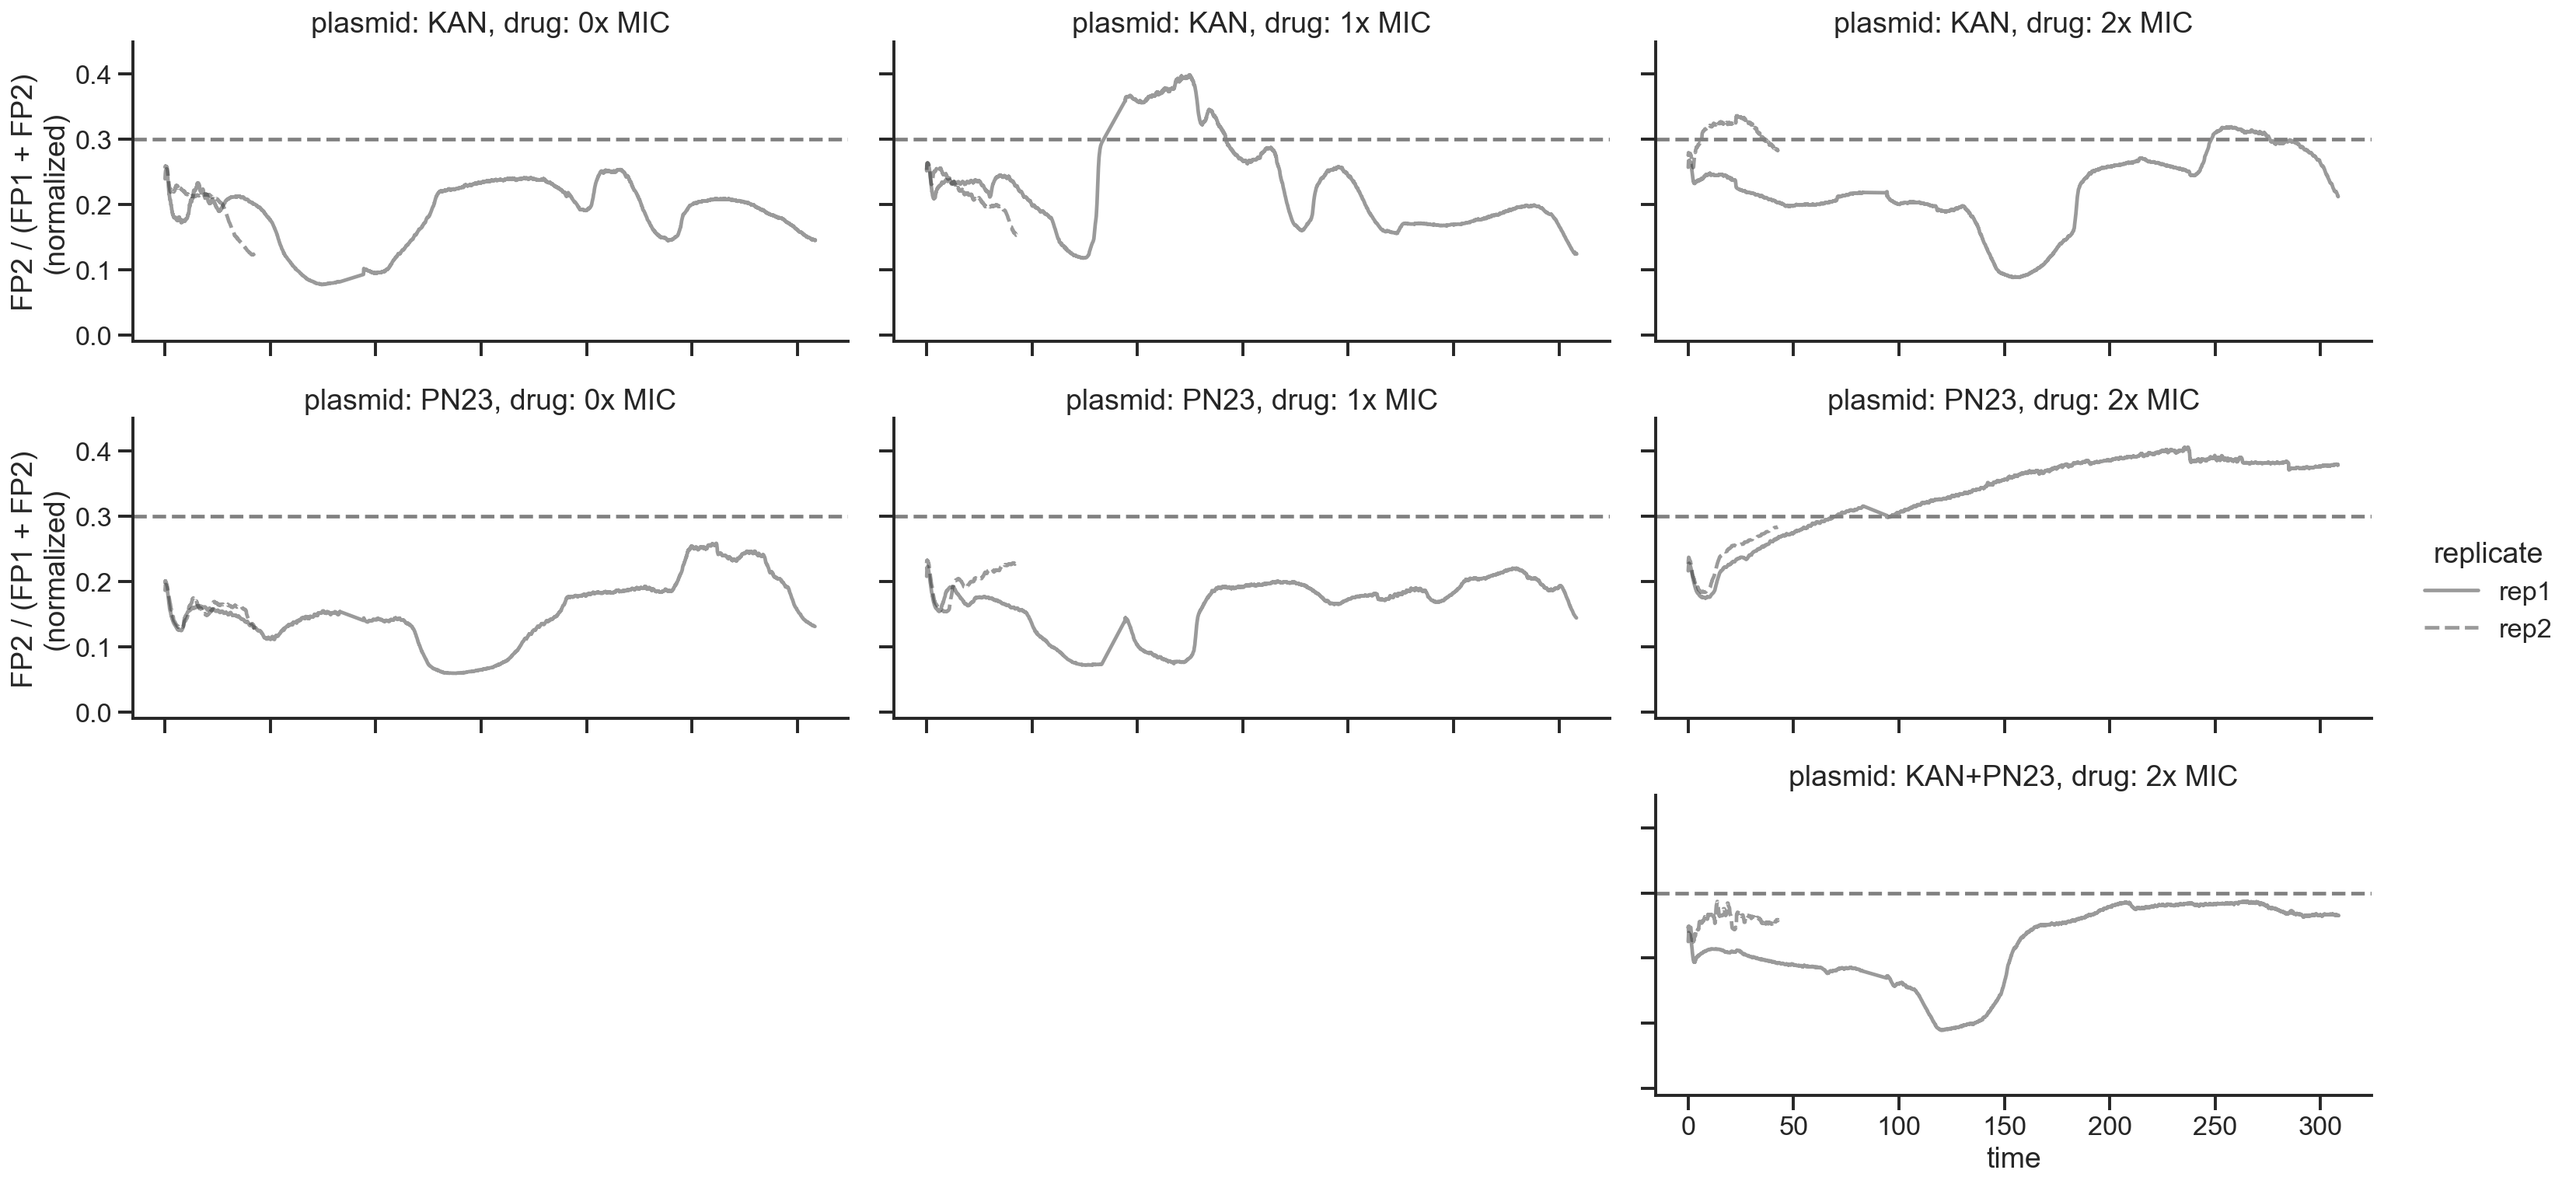

In [8]:
cp = sns.relplot(data=m,
                 x='time',
                 y='smooth_norm_FP2_emit1_FP1_emit1_proportion',
                 col='drug',
                 style='replicate',
                 row='plasmid',
                 row_order=['KAN', 'PN23', 'KAN+PN23'],
                 kind='line',
                 height=3.5, aspect=2,
                 color='xkcd:dark grey',
                 alpha=0.5,
                )

# remove axes 7 and 8
cp.axes[2, 0].set_visible(False)
cp.axes[2, 1].set_visible(False)

# cp.set(yscale='log')
cp.set_titles("plasmid: {row_name}, drug: {col_name}x MIC")
cp.set(ylabel='FP2 / (FP1 + FP2)\n(normalized)',
       # yscale='log',
       ylim=(-0.01, 0.45)
      )

cp.map(plt.axhline, y=0.3, color='grey', linestyle='--');

In [9]:
cp = c.groupby(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time', 'plate']).apply(
               lambda x: (x[x['strain'] == 'PL']['CFU/mL'].mean() /
                          x[x['strain'] == 'PM']['CFU/mL'].mean()) /
                          x['CFU/mL'].sum(),
    include_groups=False).reset_index().rename(columns={0: 'PL / PM'})

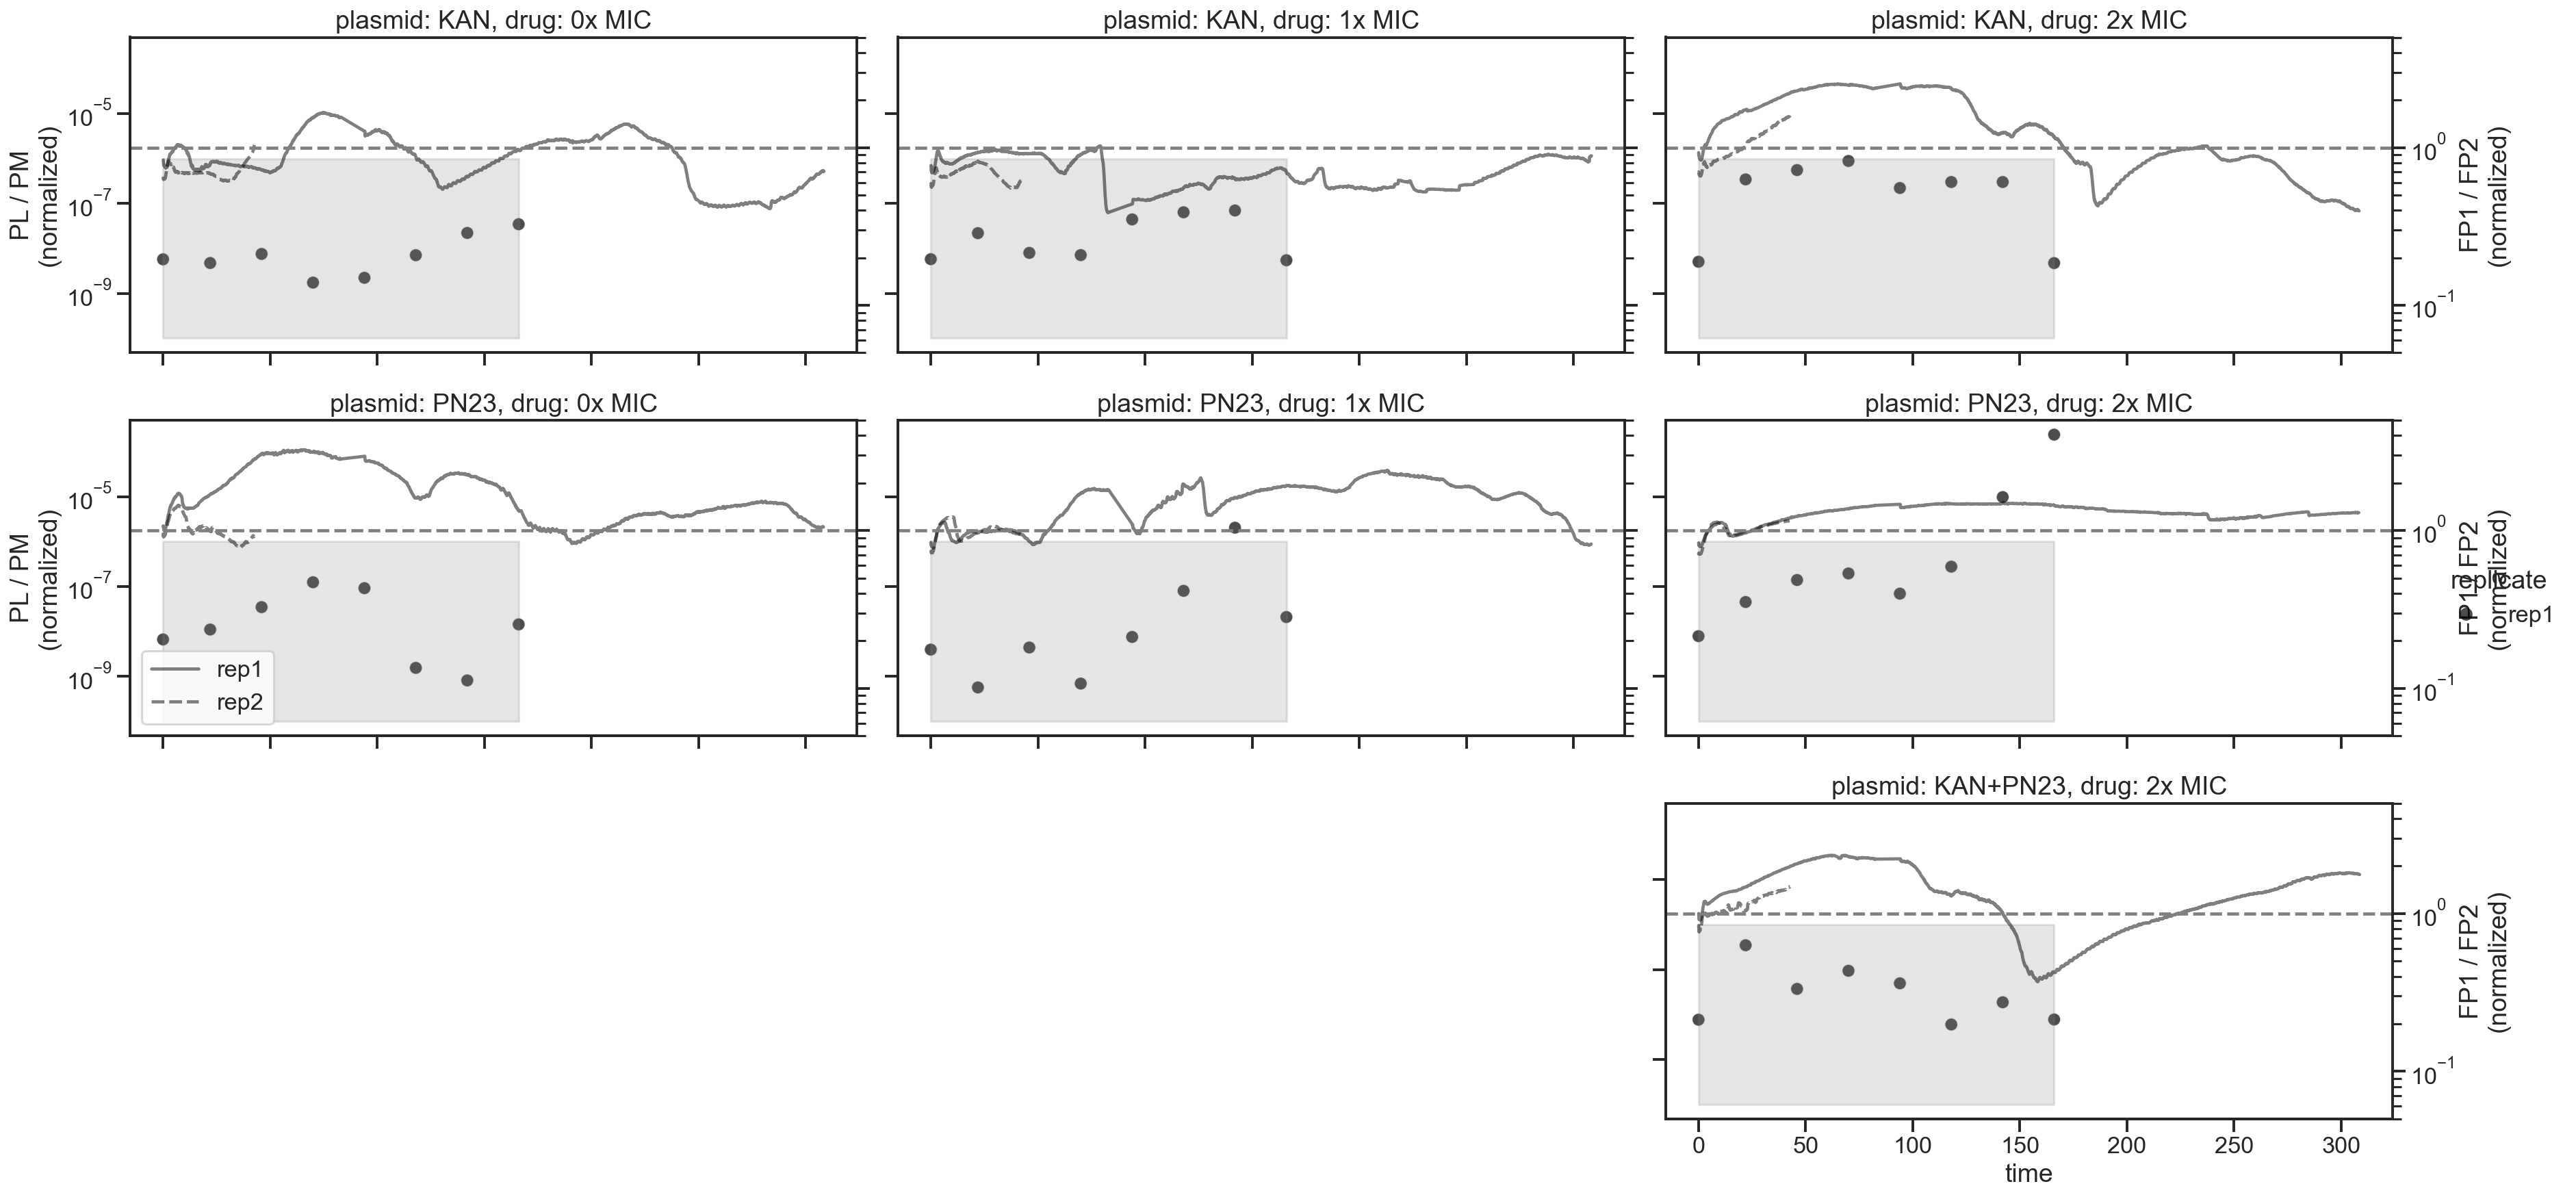

In [10]:
rp = sns.relplot(data=cp[cp['plate'] == 'KAN'],
            x='time',
            y='PL / PM',
            # hue='strain',
            col='drug',
            # col_order=['KAN', 'AMP'],
            row='plasmid',
            row_order=['KAN', 'PN23', 'KAN+PN23'],
            height=4, aspect=2,
            alpha=0.7,
            style='replicate',
            color='k',
            # palette=['xkcd:teal',
            #          'xkcd:pale red',
            #          'grey'],
            # hue_order=['PL', 'PM', 'LM']
            )

# remove axes 7 and 8
rp.axes[2, 0].set_visible(False)
rp.axes[2, 1].set_visible(False)

rp.set(yscale='log', ylabel='PL / PM\n(normalized)')
rp.set_titles("plasmid: {row_name}, drug: {col_name}x MIC")
rp.map(plt.fill_between, 
       x=sorted(cp['time'].unique()), 
       y1=1E-10, 
       y2=1E-6, 
       color='grey', 
       alpha=0.2)
fp = m.rename(columns={'smooth_norm_FP1_emit1_FP2_emit1_ratio': 'FP1 / FP2'}
             ).set_index(['time', 'short', 'plasmid',
                          'drug', 'replicate'])[['FP1 / FP2']].stack().reset_index().rename(
    columns={0: 'emission',
             'level_5': 'emitter'})
for i, ((row_val, col_val), ax_left) in enumerate(rp.axes_dict.items()):
    plasmid = row_val
    drug = col_val
    m_facet = fp[(fp['plasmid'] == plasmid) & (fp['drug'] == drug)]
    if m_facet.shape[0] == 0:
        continue

    r_ax = ax_left.twinx()

    sns.lineplot(data=m_facet.reset_index(drop=True),
                 x='time', y='emission',
                 # hue='emitter',
                 ax=r_ax,
                 # color='xkcd:dark grey',
                 alpha=0.5,
                 zorder=-1,
                 style='replicate',
                 color='k'
                 # palette=['green', 'red'],
                 # hue_order=['FP1',
                 #            'FP2']
                )

    # remove legend made by seaborn
    r_ax.legend_.remove()
    # make one that can be moved in inkscape
    if i == 3:
        r_ax.legend(facecolor='white',
                    loc='best')

    r_ax.set_ylabel('FP1 / FP2\n(normalized)')
    r_ax.set_yscale('log')
    r_ax.set_ylim(0.05, 5)

    r_ax.axhline(y=1, color='grey', linestyle='--', zorder=-1)

    # Optional: Only show the right y-label on the last column to prevent overlap
    if (i + 1) % 3:
        r_ax.set_ylabel('')
        r_ax.set_yticklabels([])

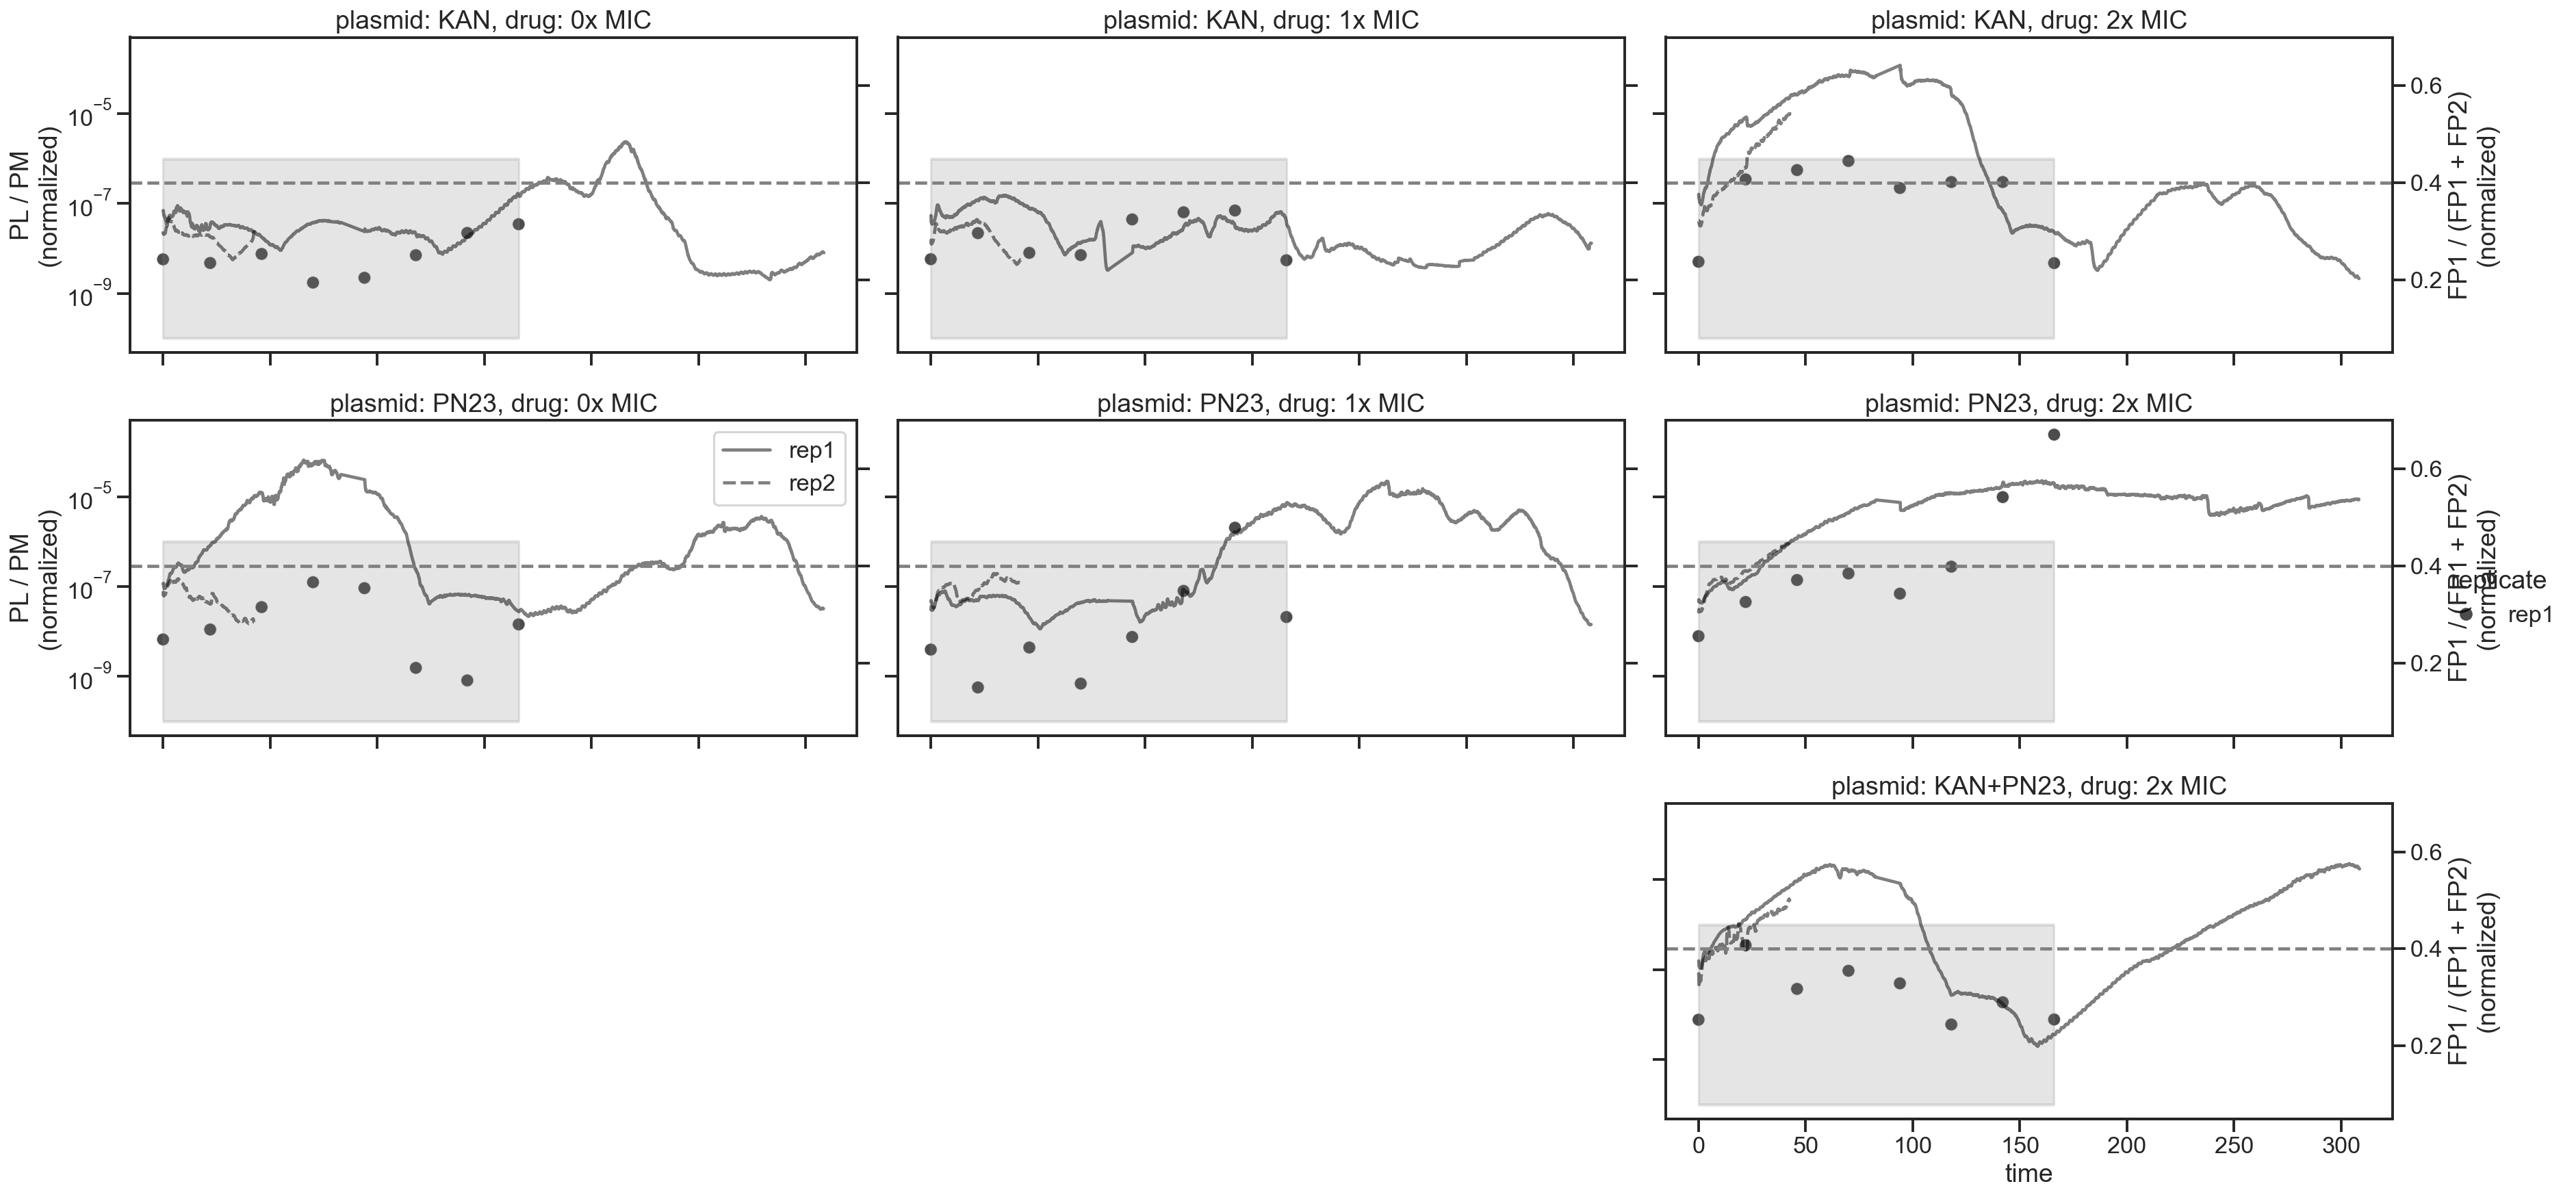

In [11]:
rp = sns.relplot(data=cp[cp['plate'] == 'KAN'],
            x='time',
            y='PL / PM',
            # hue='strain',
            col='drug',
            # col_order=['KAN', 'AMP'],
            row='plasmid',
            row_order=['KAN', 'PN23', 'KAN+PN23'],
            height=4, aspect=2,
            alpha=0.7,
            style='replicate',
            color='k',
            # palette=['xkcd:teal',
            #          'xkcd:pale red',
            #          'grey'],
            # hue_order=['PL', 'PM', 'LM']
            )

# remove axes 7 and 8
rp.axes[2, 0].set_visible(False)
rp.axes[2, 1].set_visible(False)

rp.set(yscale='log', ylabel='PL / PM\n(normalized)')
rp.set_titles("plasmid: {row_name}, drug: {col_name}x MIC")
rp.map(plt.fill_between, 
       x=cp['time'], 
       y1=1E-10, 
       y2=1E-6, 
       color='grey', 
       alpha=0.2)
fp = m.rename(columns={'smooth_norm_FP1_emit1_FP2_emit1_proportion': 'FP1 / FP2'}
             ).set_index(['time', 'short', 'plasmid',
                          'drug', 'replicate'])[['FP1 / FP2']].stack().reset_index().rename(
    columns={0: 'emission',
             'level_5': 'emitter'})
for i, ((row_val, col_val), ax_left) in enumerate(rp.axes_dict.items()):
    plasmid = row_val
    drug = col_val
    m_facet = fp[(fp['plasmid'] == plasmid) & (fp['drug'] == drug)]
    if m_facet.shape[0] == 0:
        continue

    r_ax = ax_left.twinx()

    sns.lineplot(data=m_facet.reset_index(drop=True),
                 x='time', y='emission',
                 # hue='emitter',
                 ax=r_ax,
                 # color='xkcd:dark grey',
                 alpha=0.5,
                 zorder=-1,
                 style='replicate',
                 color='k'
                 # palette=['green', 'red'],
                 # hue_order=['FP1',
                 #            'FP2']
                )

    # remove legend made by seaborn
    r_ax.legend_.remove()
    # make one that can be moved in inkscape
    if i == 3:
        r_ax.legend(facecolor='white',
                    loc='best')

    r_ax.set_ylabel('FP1 / (FP1 + FP2)\n(normalized)')
    # r_ax.set_yscale('log')
    r_ax.set_ylim(0.05, 0.7)

    r_ax.axhline(y=0.4, color='grey', linestyle='--', zorder=-1)

    # Optional: Only show the right y-label on the last column to prevent overlap
    if (i+1) % 3:
        r_ax.set_ylabel('')
        r_ax.set_yticklabels([])

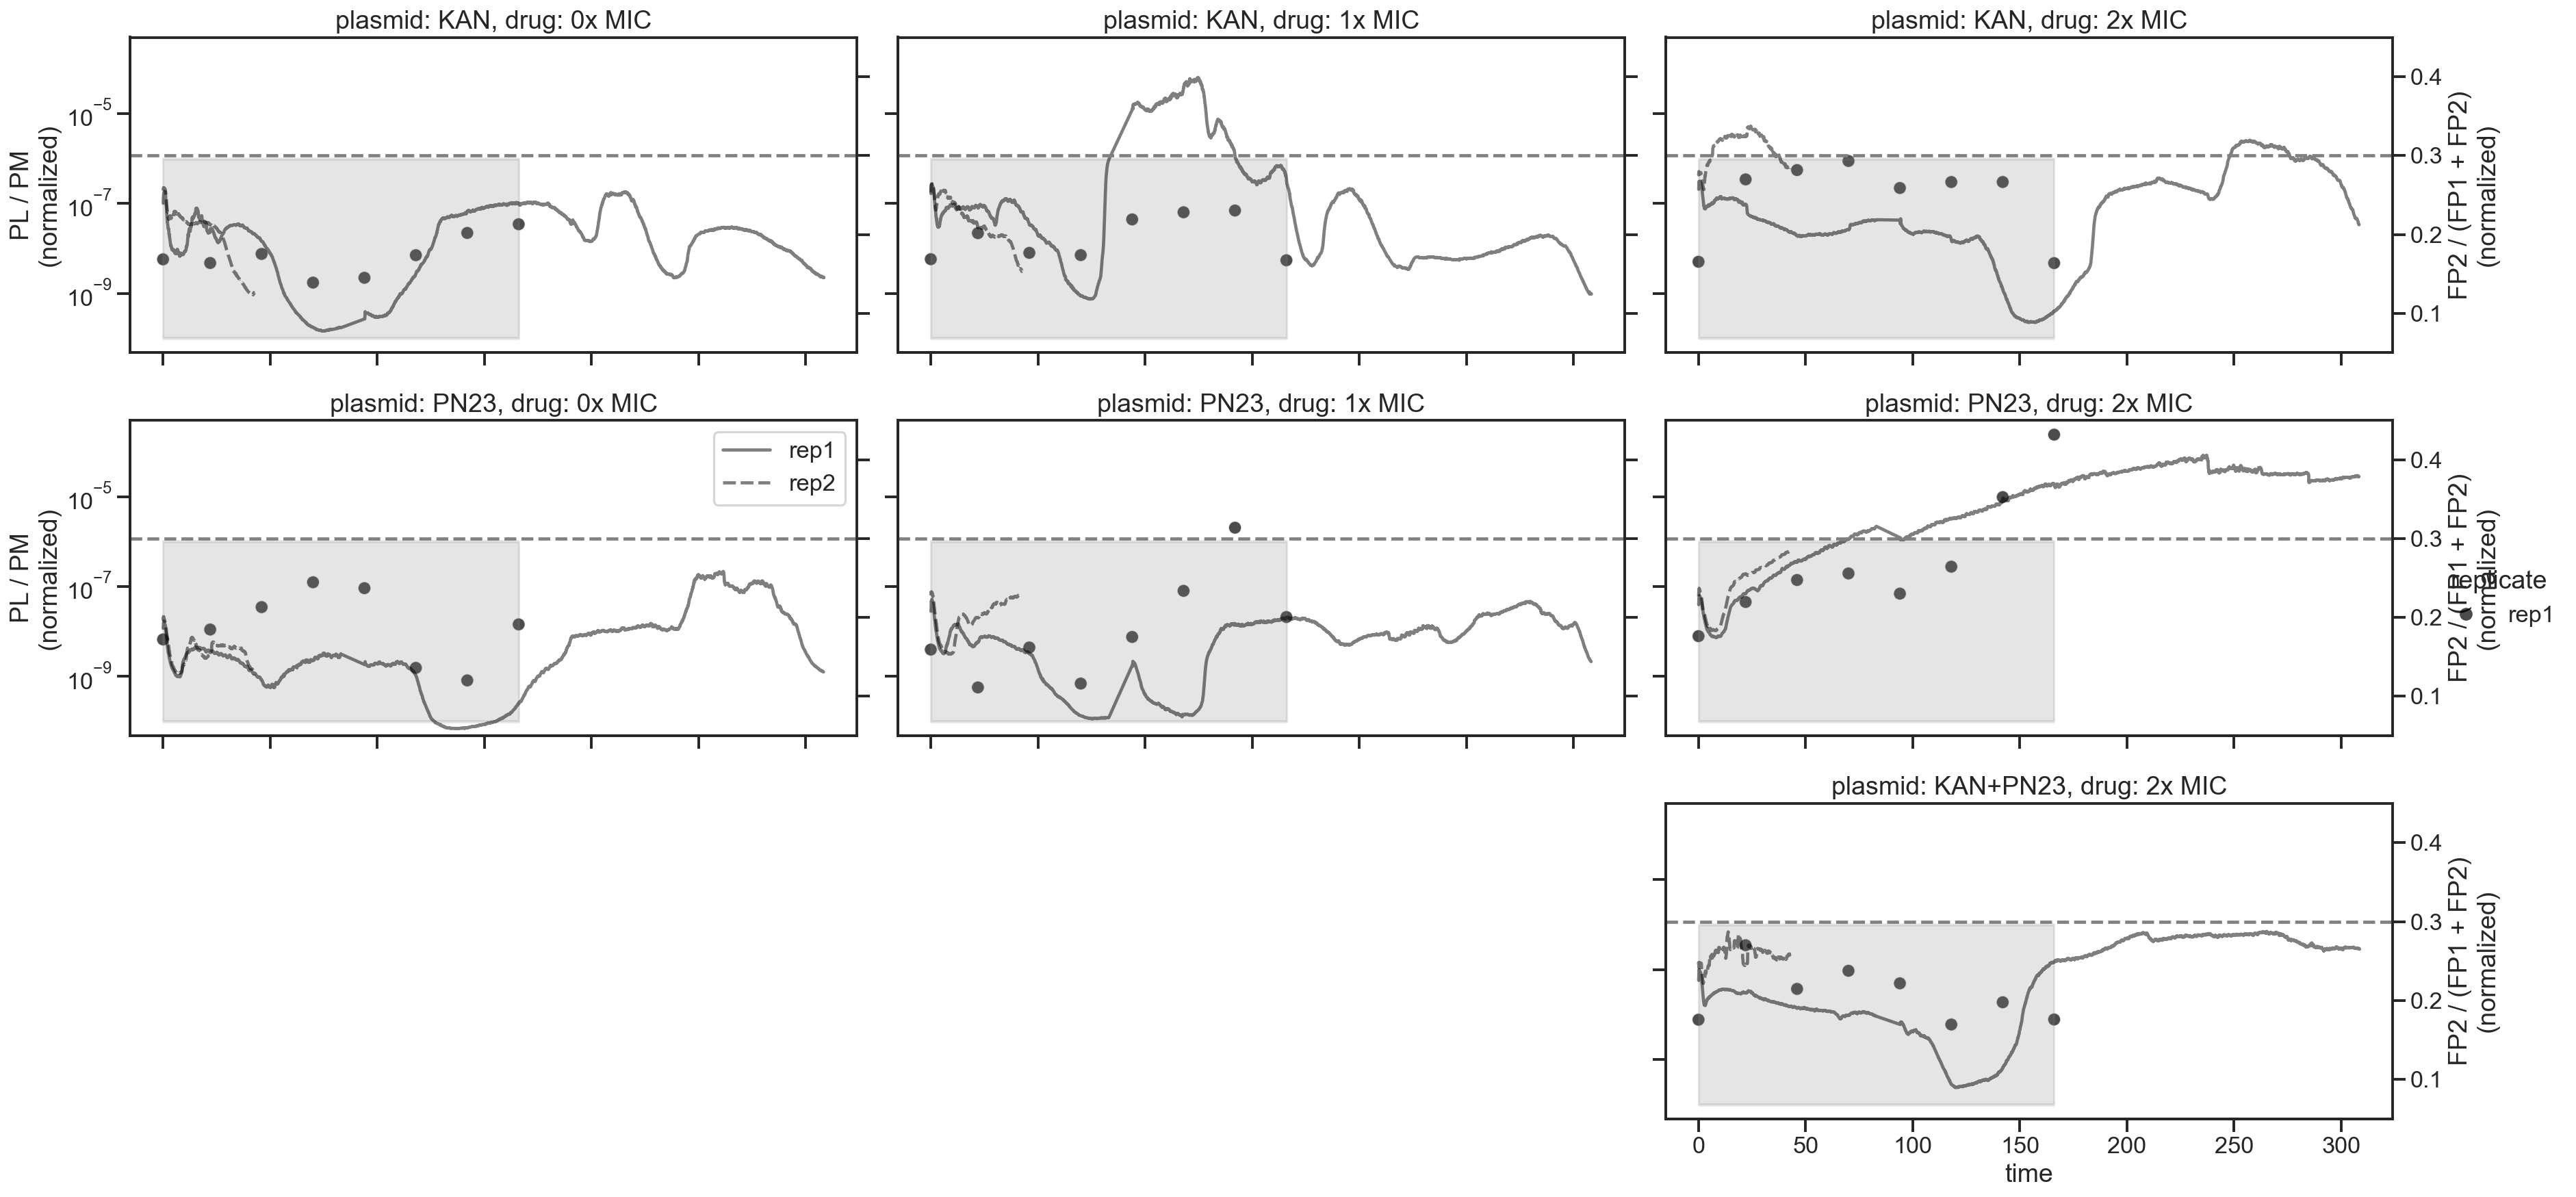

In [12]:
rp = sns.relplot(data=cp[cp['plate'] == 'KAN'],
            x='time',
            y='PL / PM',
            # hue='strain',
            col='drug',
            # col_order=['KAN', 'AMP'],
            row='plasmid',
            row_order=['KAN', 'PN23', 'KAN+PN23'],
            height=4, aspect=2,
            alpha=0.7,
            style='replicate',
            color='k',
            # palette=['xkcd:teal',
            #          'xkcd:pale red',
            #          'grey'],
            # hue_order=['PL', 'PM', 'LM']
            )

# remove axes 7 and 8
rp.axes[2, 0].set_visible(False)
rp.axes[2, 1].set_visible(False)

rp.set(yscale='log', ylabel='PL / PM\n(normalized)')
rp.set_titles("plasmid: {row_name}, drug: {col_name}x MIC")
rp.map(plt.fill_between, 
       x=cp['time'], 
       y1=1E-10, 
       y2=1E-6, 
       color='grey', 
       alpha=0.2)
fp = m.rename(columns={'smooth_norm_FP2_emit1_FP1_emit1_proportion': 'FP1 / FP2'}
             ).set_index(['time', 'short', 'plasmid',
                          'drug', 'replicate'])[['FP1 / FP2']].stack().reset_index().rename(
    columns={0: 'emission',
             'level_5': 'emitter'})
for i, ((row_val, col_val), ax_left) in enumerate(rp.axes_dict.items()):
    plasmid = row_val
    drug = col_val
    m_facet = fp[(fp['plasmid'] == plasmid) & (fp['drug'] == drug)]
    if m_facet.shape[0] == 0:
        continue

    r_ax = ax_left.twinx()

    sns.lineplot(data=m_facet.reset_index(drop=True),
                 x='time', y='emission',
                 # hue='emitter',
                 ax=r_ax,
                 # color='xkcd:dark grey',
                 alpha=0.5,
                 zorder=-1,
                 style='replicate',
                 color='k'
                 # palette=['green', 'red'],
                 # hue_order=['FP1',
                 #            'FP2']
                )

    # remove legend made by seaborn
    r_ax.legend_.remove()
    # make one that can be moved in inkscape
    if i == 3:
        r_ax.legend(facecolor='white',
                    loc='best')

    r_ax.set_ylabel('FP2 / (FP1 + FP2)\n(normalized)')
    # r_ax.set_yscale('log')
    r_ax.set_ylim(0.05, 0.45)

    r_ax.axhline(y=0.3, color='grey', linestyle='--', zorder=-1)

    # Optional: Only show the right y-label on the last column to prevent overlap
    if (i + 1) % 3:
        r_ax.set_ylabel('')
        r_ax.set_yticklabels([])

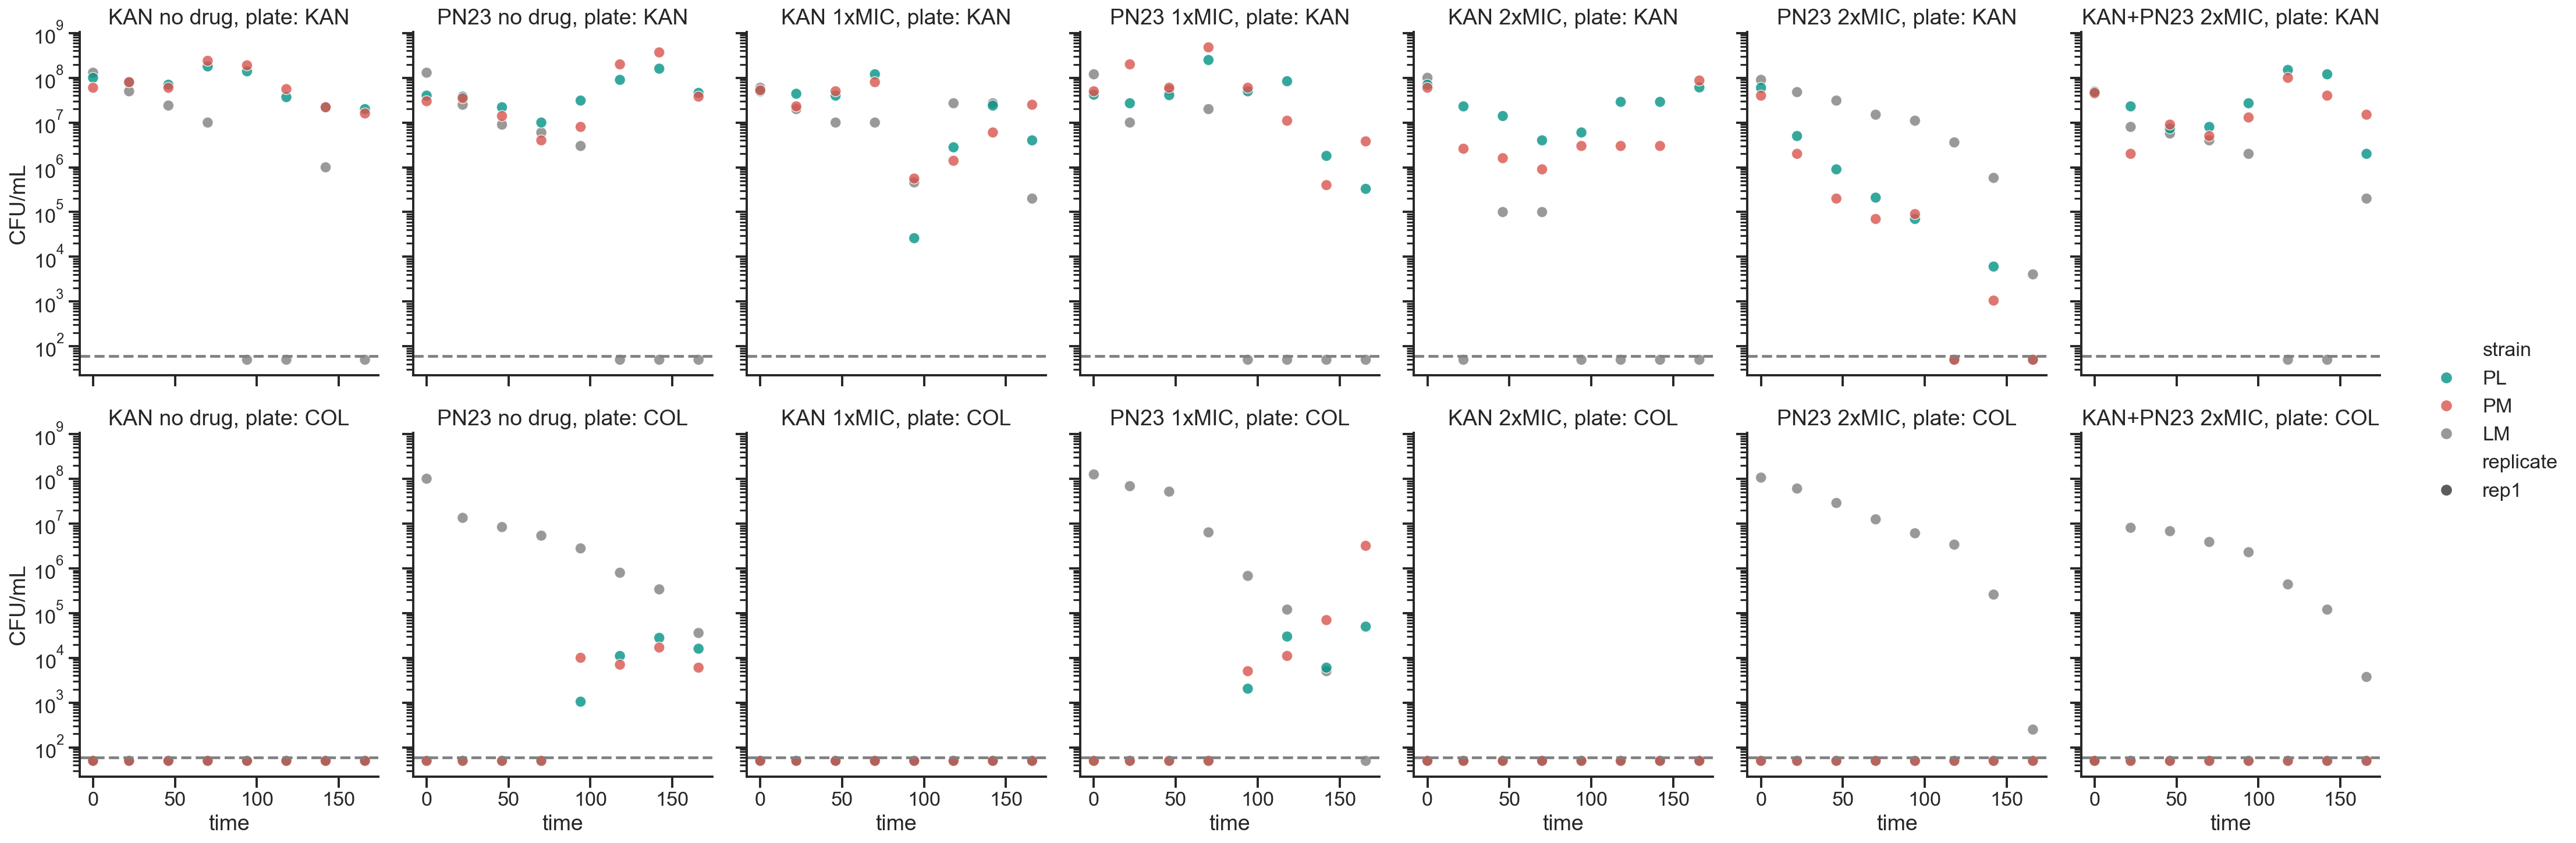

In [13]:
cp = sns.relplot(data=c,
                 x='time',
                 y='CFU/mL',
                 hue='strain',
                 col='short',
                 col_order=short_order,
                 style='replicate',
                 row_order=['KAN', 'COL'],
                 row='plate',
                 height=5, aspect=0.8,
                 alpha=0.8,
                 palette=['xkcd:teal',
                          'xkcd:pale red',
                          'grey'],
                 hue_order=['PL', 'PM', 'LM'])

cp.set(yscale='log')
cp.set_titles("{col_name}, plate: {row_name}")
cp.map(plt.axhline, y=60, color='grey', linestyle='--');

In [14]:
# cp = sns.relplot(data=f,
#                  x='time',
#                  y='proportion',
#                  hue='strain',
#                  col='plasmid',
#                  row='drug',
#                  style='replicate',
#                  height=4.5, aspect=1,
#                  alpha=0.8,
#                  palette=['xkcd:teal',
#                           'xkcd:pale red',
#                           'grey'],
#                  hue_order=['PL', 'PM', 'LM'])

# # cp.set(yscale='log')
# cp.set_titles("plasmid: {col_name}, AMP: {row_name}x MIC")
# cp.map(plt.axhline, y=.3, color='grey', linestyle='--');

In [15]:
# cp = sns.relplot(data=p,
#                  x='time',
#                  y='emission',
#                  hue='wavelength',
#                  col='plasmid',
#                  row='drug',
#                  style='replicate',
#                  # col_wrap=4,
#                  height=5, aspect=1,
#                  alpha=0.8,
#                  palette=['xkcd:pale red',
#                           'xkcd:teal'])

# cp.set(yscale='log', 
#        # ylim=(10, 16000)
#       )
# cp.set_titles("plasmid: {col_name}, AMP: {row_name}x MIC");
# # cp.map(plt.axhline, y=.3, color='grey', linestyle='--');